# **Importaçâo de bibliotecas e arquivos não tratados**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as date

In [39]:
loja = pd.read_csv("/content/drive/MyDrive/Sistematização - AEE/LojasOpcaoA.csv")
venda = pd.read_csv("/content/drive/MyDrive/Sistematização - AEE/VendasOpcaoA.csv")

#**Tratamento do DataFrame Lojas**

In [40]:
loja

,loja_id,loja,cidade,estado,região,tamanho_loja,quantidade_funcionarios,gerente,data_inauguracao
0,1,Loja Asa Sul,Brasília,DF,Centro-Oeste,Grande,45,Ana Paula,2018-03-10
1,2,Loja Taguatinga,taguatinga,df,Centro Oeste,Média,30,Bruno Silva,2019-07-21
2,3,Loja Goiânia,Goiânia,GO,Centro-Oeste,NaN,28,Carla Souza,2020-13-01
3,4,Loja Anápolis,Anápolis,GO,Centro-Oeste,Pequena,15,Daniel Costa,2021-05-14
4,5,Loja Plano Piloto,Brasília,DF,Centro-Oeste,Grande,60,Eva Martins,2017-11-30
5,3,Loja Goiânia,Goiânia,GO,Centro-Oeste,NaN,28,Carla Souza,2020-13-01


In [41]:
loja.describe()

,loja_id,quantidade_funcionarios
count,6.000000,6.000000
mean,3.000000,34.333333
std,1.414214,15.781846
min,1.000000,15.000000
25%,2.250000,28.000000
50%,3.000000,29.000000
75%,3.750000,41.250000
max,5.000000,60.000000


In [42]:
loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   loja_id                  6 non-null      int64 
 1   loja                     6 non-null      object
 2   cidade                   6 non-null      object
 3   estado                   6 non-null      object
 4   região                   6 non-null      object
 5   tamanho_loja             4 non-null      object
 6   quantidade_funcionarios  6 non-null      int64 
 7   gerente                  6 non-null      object
 8   data_inauguracao         6 non-null      object
dtypes: int64(2), object(7)
memory usage: 564.0+ bytes


In [43]:
loja.isnull().sum()

,0
loja_id,0
loja,0
cidade,0
estado,0
região,0
tamanho_loja,2
quantidade_funcionarios,0
gerente,0
data_inauguracao,0


In [44]:
loja = loja.fillna(value={"tamanho_loja": "Não Informado"})

In [45]:
print(loja.shape)

(6, 9)


In [46]:
print(loja.duplicated().sum())

1


In [47]:
print(loja['estado'].value_counts())
print(loja['região'].value_counts())
print(loja['tamanho_loja'].value_counts())

estado
GO    3
DF    2
df    1
Name: count, dtype: int64
região
Centro-Oeste    5
Centro Oeste    1
Name: count, dtype: int64
tamanho_loja
Grande           2
Não Informado    2
Média            1
Pequena          1
Name: count, dtype: int64


In [48]:
loja.duplicated().sum()

np.int64(1)

In [49]:
loja = loja.drop_duplicates()

In [50]:
loja['estado'] = loja['estado'].str.strip().str.upper()
loja['região'] = loja['região'].str.strip().str.upper()
loja['tamanho_loja'] = loja['tamanho_loja'].str.strip().str.upper()
loja['loja'] = loja['loja'].str.strip().str.upper()
loja['cidade'] = loja['cidade'].str.strip().str.upper()
loja['gerente'] = loja['gerente'].str.strip().str.upper()

In [51]:
loja

,loja_id,loja,cidade,estado,região,tamanho_loja,quantidade_funcionarios,gerente,data_inauguracao
0,1,LOJA ASA SUL,BRASÍLIA,DF,CENTRO-OESTE,GRANDE,45,ANA PAULA,2018-03-10
1,2,LOJA TAGUATINGA,TAGUATINGA,DF,CENTRO OESTE,MÉDIA,30,BRUNO SILVA,2019-07-21
2,3,LOJA GOIÂNIA,GOIÂNIA,GO,CENTRO-OESTE,NÃO INFORMADO,28,CARLA SOUZA,2020-13-01
3,4,LOJA ANÁPOLIS,ANÁPOLIS,GO,CENTRO-OESTE,PEQUENA,15,DANIEL COSTA,2021-05-14
4,5,LOJA PLANO PILOTO,BRASÍLIA,DF,CENTRO-OESTE,GRANDE,60,EVA MARTINS,2017-11-30


#**Tratamento do DataFrame Vendas**

In [52]:
venda

,id_venda,data,loja_id,categoria,produto,vendedor,cliente_id,idade_cliente,sexo,quantidade,valor_unitario,valor_total,forma_pagamento
0,31,2025-04-05,3,ELETRÔNICOS,Mouse,Carlos,9666,18.0,f,8,2087.69,-16701.52,Pix
1,68,2025-02-18,2,Eletrônicos,Mouse,Fernanda,8800,59.0,m,7,1231.67,8621.69,Boleto
2,63,2025-01-31,3,alimentos,Arroz,João,9289,59.0,f,6,1341.21,8047.26,Pix
3,48,2025-01-19,4,eletronicos,Jaqueta,Ana,7547,33.0,F,4,1801.50,7206.00,Pix
4,43,2025-06-20,1,eletrônicos,TV,Fernanda,5920,50.0,f,6,1665.20,9991.20,Boleto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,61,31/15/2025,1,ELETRÔNICOS,Teclado,Lucas,3683,37.0,M,3,1522.61,4567.83,NaN
98,72,2025-02-19,1,ELETRÔNICOS,Mouse,Fernanda,9751,26.0,f,6,465.02,2790.12,Pix
99,15,2025-05-19,1,alimentos,Arroz,Pedro,6038,33.0,M,6,1231.74,7390.44,Cartão
100,93,2025-04-09,4,eletrônicos,Monitor,Fernanda,7246,42.0,F,1,809.08,809.08,Boleto


In [53]:
venda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venda         102 non-null    int64  
 1   data             102 non-null    object 
 2   loja_id          102 non-null    int64  
 3   categoria        101 non-null    object 
 4   produto          100 non-null    object 
 5   vendedor         102 non-null    object 
 6   cliente_id       102 non-null    int64  
 7   idade_cliente    99 non-null     float64
 8   sexo             102 non-null    object 
 9   quantidade       102 non-null    int64  
 10  valor_unitario   102 non-null    float64
 11  valor_total      102 non-null    float64
 12  forma_pagamento  78 non-null     object 
dtypes: float64(3), int64(4), object(6)
memory usage: 10.5+ KB


In [54]:
venda.describe()

,id_venda,loja_id,cliente_id,idade_cliente,quantidade,valor_unitario,valor_total
count,102.000000,102.000000,102.000000,99.000000,102.000000,102.000000,102.000000
mean,50.137255,5.019608,5758.813725,44.666667,4.901961,1208.697549,5488.112353
std,28.961921,12.670993,2728.077090,14.998639,2.173239,723.915007,5164.244446
min,1.000000,1.000000,1153.000000,18.000000,1.000000,24.190000,-16701.520000
25%,25.250000,2.000000,3273.250000,33.000000,3.000000,615.525000,2107.540000
50%,50.500000,3.500000,5917.500000,47.000000,5.000000,1102.120000,4287.830000
75%,74.750000,4.000000,8412.250000,57.500000,7.000000,1874.230000,8046.632500
max,100.000000,99.000000,9947.000000,70.000000,8.000000,2499.770000,18663.840000


In [55]:
venda.duplicated().sum()

np.int64(2)

In [56]:
venda.shape

(102, 13)

In [79]:
venda['data'] = pd.to_datetime(
    venda['data'],
    errors='coerce'
)

venda['valor_unitario'] = pd.to_numeric(
    venda['valor_unitario'],
    errors='coerce'
)

venda['valor_total'] = pd.to_numeric(
    venda['valor_total'],
    errors='coerce'
)

In [58]:
venda = venda.drop_duplicates()

In [59]:
venda.isnull().sum()

,0
id_venda,0
data,2
loja_id,0
categoria,1
produto,2
vendedor,0
cliente_id,0
idade_cliente,3
sexo,0
quantidade,0


In [74]:
venda = venda.fillna(value={"data": 0})
venda = venda.fillna(value={"categoria": "Não Informado"})
venda = venda.fillna(value={"produto": "Não Informado"})
venda = venda.fillna(value={"idade_cliente": 0})
venda = venda.fillna(value={"forma_pagamento": "Não Informado"})

In [61]:
print(venda['categoria'].value_counts())
print(venda['produto'].value_counts())
print(venda['vendedor'].value_counts())

categoria
 alimentos       17
eletrônicos      17
ELETRÔNICOS      16
Alimentos        14
Vestuário        12
Eletrônicos      11
vestuário         9
eletronicos       1
 eletrônicos      1
Não Informado     1
ELETRONICOS       1
Name: count, dtype: int64
produto
TV               11
Teclado          11
Macarrão         10
Feijão           10
Camisa            8
Notebook          8
Mouse             7
Monitor           7
Café              7
Tênis             5
Calça             5
Arroz             4
Jaqueta           4
Não Informado     2
 Notebook         1
Name: count, dtype: int64
vendedor
Fernanda    20
Lucas       17
Pedro       15
Carlos      15
João        13
 Ana        10
Maria        9
 João        1
Name: count, dtype: int64


In [62]:
venda['categoria'] = venda['categoria'].str.strip().str.upper()
venda['produto'] = venda['produto'].str.strip().str.upper()
venda['vendedor'] = venda['vendedor'].str.strip().str.upper()
venda['sexo'] = venda['sexo'].str.strip().str.upper()

In [63]:
venda['categoria'] = venda[
    'categoria'
].replace(
    {
        "ELETRONICOS":"ELETRÔNICOS",
        "VESTUARIOS ":"VESTUÁRIOS",
        "ORTOP":"ELETRÔNICOS"
    }
)

In [64]:
venda

,id_venda,data,loja_id,categoria,produto,vendedor,cliente_id,idade_cliente,sexo,quantidade,valor_unitario,valor_total,forma_pagamento
0,31,2025-04-05 00:00:00,3,ELETRÔNICOS,MOUSE,CARLOS,9666,18.0,F,8,2087.69,-16701.52,Pix
1,68,2025-02-18 00:00:00,2,ELETRÔNICOS,MOUSE,FERNANDA,8800,59.0,M,7,1231.67,8621.69,Boleto
2,63,2025-01-31 00:00:00,3,ALIMENTOS,ARROZ,JOÃO,9289,59.0,F,6,1341.21,8047.26,Pix
3,48,2025-01-19 00:00:00,4,ELETRÔNICOS,JAQUETA,ANA,7547,33.0,F,4,1801.50,7206.00,Pix
4,43,2025-06-20 00:00:00,1,ELETRÔNICOS,TV,FERNANDA,5920,50.0,F,6,1665.20,9991.20,Boleto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,61,Não Informado,1,ELETRÔNICOS,TECLADO,LUCAS,3683,37.0,M,3,1522.61,4567.83,Não Informado
98,72,2025-02-19 00:00:00,1,ELETRÔNICOS,MOUSE,FERNANDA,9751,26.0,F,6,465.02,2790.12,Pix
99,15,2025-05-19 00:00:00,1,ALIMENTOS,ARROZ,PEDRO,6038,33.0,M,6,1231.74,7390.44,Cartão
100,93,2025-04-09 00:00:00,4,ELETRÔNICOS,MONITOR,FERNANDA,7246,42.0,F,1,809.08,809.08,Boleto




```
# Validando o valor total do DataFrame Vendas
```



In [65]:
venda['valor_calculado'] = (
    venda['quantidade'] *
    venda['valor_unitario']
)

In [66]:
venda[
    venda['valor_total'] != venda['valor_calculado']
]

,id_venda,data,loja_id,categoria,produto,vendedor,cliente_id,idade_cliente,sexo,quantidade,valor_unitario,valor_total,forma_pagamento,valor_calculado
0,31,2025-04-05 00:00:00,3,ELETRÔNICOS,MOUSE,CARLOS,9666,18.0,F,8,2087.69,-16701.52,Pix,16701.52
8,11,2025-04-13 00:00:00,1,ELETRÔNICOS,NÃO INFORMADO,LUCAS,1771,25.0,F,3,1283.63,3850.89,Cartão,3850.89
15,5,2025-04-28 00:00:00,3,VESTUÁRIO,CAMISA,LUCAS,6925,54.0,F,7,215.42,1507.94,Pix,1507.94
17,34,2025-03-27 00:00:00,4,ALIMENTOS,FEIJÃO,CARLOS,8007,53.0,M,5,420.72,2103.60,Não Informado,2103.60
18,13,2025-06-24 00:00:00,4,VESTUÁRIO,TÊNIS,MARIA,8433,18.0,F,6,296.65,1779.90,Não Informado,1779.90
27,74,2025-05-03 00:00:00,3,VESTUÁRIO,TÊNIS,LUCAS,8827,25.0,M,3,2414.43,7243.29,Boleto,7243.29
29,10,2025-06-14 00:00:00,5,VESTUÁRIO,CALÇA,CARLOS,5304,65.0,M,5,366.28,1831.40,Não Informado,1831.40
30,85,2025-01-10 00:00:00,1,VESTUÁRIO,CAMISA,LUCAS,7622,50.0,M,6,645.95,3875.70,Não Informado,3875.70
51,50,2025-04-27 00:00:00,4,ELETRÔNICOS,MONITOR,CARLOS,9270,45.0,M,6,2376.10,14256.60,Cartão,14256.60
53,25,2025-03-09 00:00:00,5,ALIMENTOS,CAFÉ,FERNANDA,8973,27.0,F,5,1069.06,5345.30,Dinheiro,5345.30


In [67]:
venda['valor_total'] = venda['valor_calculado']

In [68]:
venda.drop(
    columns='valor_calculado',
    inplace=True
)

#**Engenharia de atributos**



```
1° Mês da venda
```

In [80]:
venda['mês_venda'] = venda['data'].dt.month_name()

In [107]:
venda['mês_venda'] = venda[
    'mês_venda'
].replace(
    {
        'January':'Janeiro',
        'February':'Fevereiro',
        'March':'Março',
        'April':'Abril',
        'May':'Maio',
        'June':'Junho',
        'July':'Julho',
        'August':'Agosto',
        'September':'Setembro',
        'October':'Outubro',
        'November':'Novembro',
        'December':'Dezembro'
    }
)

In [111]:
venda = venda.fillna(value={"mês_venda": "Não Informado"})

```
2° Ano da venda
```

In [83]:
venda['ano_venda'] = venda['data'].dt.year

In [84]:
venda['ano_venda'].dtype

dtype('float64')

In [85]:
venda['ano_venda'] = pd.to_numeric(
    venda['ano_venda'],
    errors='coerce'
)

In [86]:
venda['ano_venda'].isna().sum()

np.int64(2)

In [87]:
venda['ano_venda'] = venda['ano_venda'].astype('Int64')

In [88]:
venda['ano_venda'] = venda['ano_venda'].fillna(0).astype(int)

```
3° Faixa etária
```

In [89]:
venda['idade_cliente'].dtype

dtype('float64')

In [90]:
venda['idade_cliente'].unique()

array([18., 59., 33., 50., 25., 27.,  0., 61., 20., 56., 58., 29., 54.,
       62., 53., 49., 66., 48., 47., 57., 26., 55., 65., 64., 35., 40.,
       63., 45., 38., 36., 31., 68., 22., 69., 24., 41., 67., 44., 37.,
       46., 70., 42., 32., 23.])

In [91]:
venda['idade_cliente'] = pd.to_numeric(
    venda['idade_cliente'],
    errors='coerce'
)

In [92]:
venda['idade_cliente'] = venda['idade_cliente'].astype(int)

In [93]:
venda['idade_cliente'].isnull().sum()

np.int64(0)

In [94]:
venda = venda.fillna(value={'idade_cliente': 0})

In [95]:
venda['faixa_etaria'] = pd.cut(
    venda['idade_cliente'],
    bins=[0,18,30,45,60,100],
    labels=[
        'Ate 18',
        '19-30',
        '31-45',
        '46-60',
        '60+'
    ]
)

```
4° Classificação da venda
```

In [96]:
venda['classe_venda'] = pd.cut(
    venda['valor_total'],
    bins=[0,100,500,1000,100000],
    labels=[
        'Baixa',
        'Media',
        'Alta',
        'Muito Alta'
    ]
)

```
5° Porte da loja
```

In [97]:
loja['porte_loja'] = pd.cut(
    loja['quantidade_funcionarios'],
    bins=[0,100,500,1000,100000],
    labels=[
        'Pequena',
        'Media',
        'Grande',
        'Muito Grande'
    ]
)

#**Validação das tabelas**

In [98]:
vendas_sem_loja = venda['loja_id'].isin(loja.index).all()

print(vendas_sem_loja)

False


#**Gráficos**

```
Vendas por categoria
```

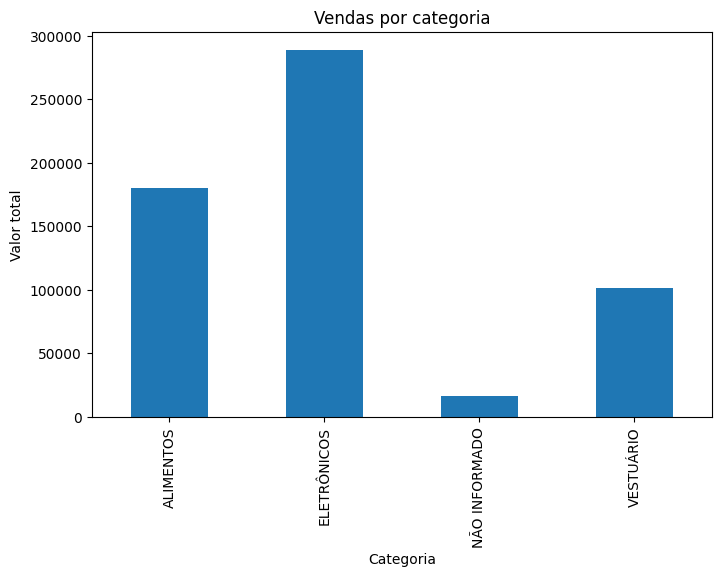

In [99]:
venda.groupby('categoria')['valor_total'].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Vendas por categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor total')
plt.show()

```
Faturamento por loja
```

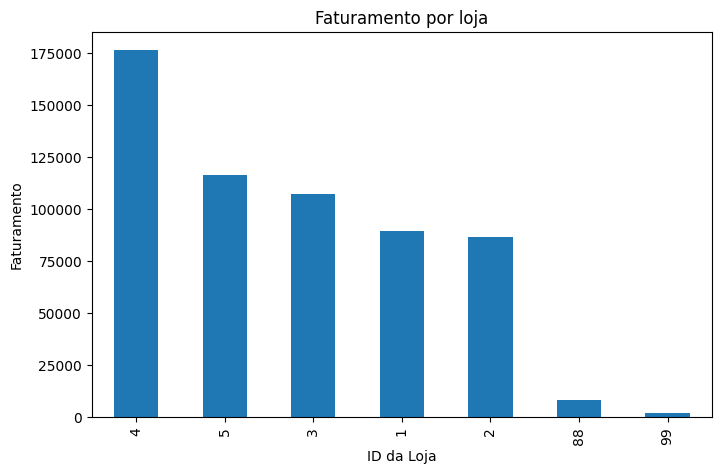

In [100]:
venda.groupby('loja_id')['valor_total'].sum().sort_values(
    ascending=False
).head(10).plot(kind='bar', figsize=(8,5))

plt.title('Faturamento por loja')
plt.xlabel('ID da Loja')
plt.ylabel('Faturamento')
plt.show()

```
Distribuição de idade
```

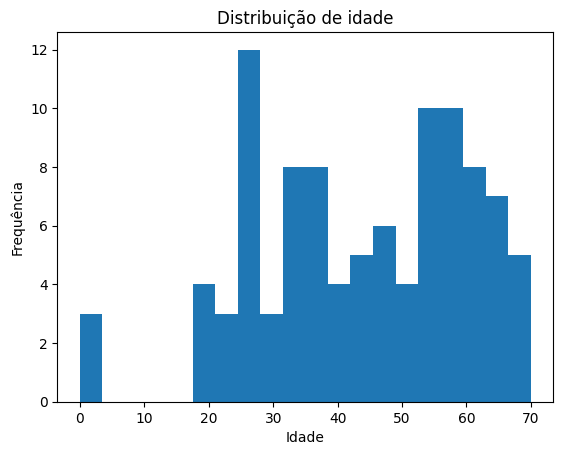

In [101]:
plt.hist(venda['idade_cliente'], bins=20)
plt.title('Distribuição de idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

```
Forma de pagamento
```

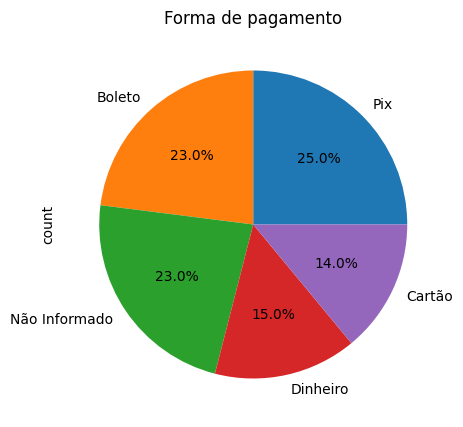

In [102]:
venda['forma_pagamento'].value_counts().plot(
    kind='pie',
    figsize=(8,5),
    autopct='%1.1f%%'
)

plt.title('Forma de pagamento')
plt.show()

```
Evolução mensal
```

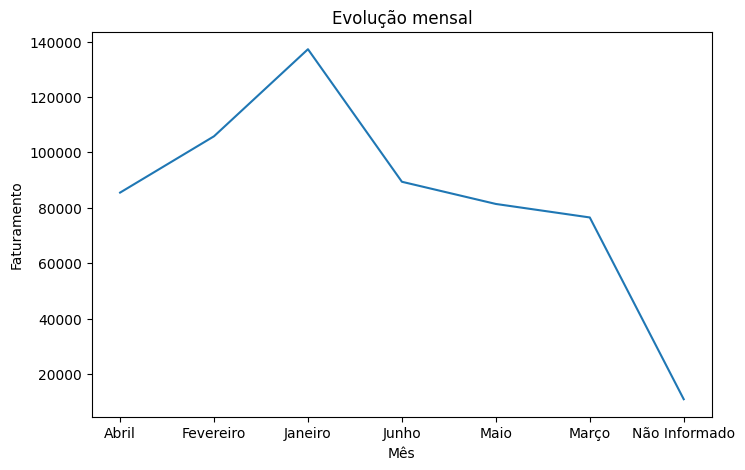

In [112]:
venda.groupby('mês_venda')['valor_total'].sum().plot(
    kind='line',
    figsize=(8,5)
)

plt.title('Evolução mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento')
plt.show()

In [116]:
loja

,index,loja_id,loja,cidade,estado,região,tamanho_loja,quantidade_funcionarios,gerente,data_inauguracao,porte_loja
0,0,1,LOJA ASA SUL,BRASÍLIA,DF,CENTRO-OESTE,GRANDE,45,ANA PAULA,2018-03-10,Pequena
1,1,2,LOJA TAGUATINGA,TAGUATINGA,DF,CENTRO OESTE,MÉDIA,30,BRUNO SILVA,2019-07-21,Pequena
2,2,3,LOJA GOIÂNIA,GOIÂNIA,GO,CENTRO-OESTE,NÃO INFORMADO,28,CARLA SOUZA,2020-13-01,Pequena
3,3,4,LOJA ANÁPOLIS,ANÁPOLIS,GO,CENTRO-OESTE,PEQUENA,15,DANIEL COSTA,2021-05-14,Pequena
4,4,5,LOJA PLANO PILOTO,BRASÍLIA,DF,CENTRO-OESTE,GRANDE,60,EVA MARTINS,2017-11-30,Pequena


In [113]:
venda

,id_venda,data,loja_id,categoria,produto,vendedor,cliente_id,idade_cliente,sexo,quantidade,valor_unitario,valor_total,forma_pagamento,mês_venda,ano_venda,faixa_etaria,classe_venda
0,31,2025-04-05,3,ELETRÔNICOS,MOUSE,CARLOS,9666,18,F,8,2087.69,16701.52,Pix,Abril,2025,Ate 18,Muito Alta
1,68,2025-02-18,2,ELETRÔNICOS,MOUSE,FERNANDA,8800,59,M,7,1231.67,8621.69,Boleto,Fevereiro,2025,46-60,Muito Alta
2,63,2025-01-31,3,ALIMENTOS,ARROZ,JOÃO,9289,59,F,6,1341.21,8047.26,Pix,Janeiro,2025,46-60,Muito Alta
3,48,2025-01-19,4,ELETRÔNICOS,JAQUETA,ANA,7547,33,F,4,1801.50,7206.00,Pix,Janeiro,2025,31-45,Muito Alta
4,43,2025-06-20,1,ELETRÔNICOS,TV,FERNANDA,5920,50,F,6,1665.20,9991.20,Boleto,Junho,2025,46-60,Muito Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,61,NaT,1,ELETRÔNICOS,TECLADO,LUCAS,3683,37,M,3,1522.61,4567.83,Não Informado,Não Informado,0,31-45,Muito Alta
98,72,2025-02-19,1,ELETRÔNICOS,MOUSE,FERNANDA,9751,26,F,6,465.02,2790.12,Pix,Fevereiro,2025,19-30,Muito Alta
99,15,2025-05-19,1,ALIMENTOS,ARROZ,PEDRO,6038,33,M,6,1231.74,7390.44,Cartão,Maio,2025,31-45,Muito Alta
100,93,2025-04-09,4,ELETRÔNICOS,MONITOR,FERNANDA,7246,42,F,1,809.08,809.08,Boleto,Abril,2025,31-45,Alta


In [114]:
loja = loja.reset_index()

In [115]:
venda.to_csv(
    'vendas_corrigido.csv',
    index=False
)

loja.to_csv(
    'lojas_corrigido.csv',
    index=False
)